### 시설부하지수 (집중관리구역 설정 및 근거)

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
import koreanize_matplotlib

merge_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv")

In [3]:
# 가중 시설 점수 (EV×4 + ES×1)
merge_df['TOTAL_W'] = merge_df['EV']*4 + merge_df['ES']*1

# 시설부하지수 = 무임승하차 / 가중 시설 점수
merge_df['시설부하지수'] = (merge_df['무임승하차'] / merge_df['TOTAL_W']).round(2)

### 시설부하지수 분포 확인

분포 먼저 확인하는 이유는 20% 설정 값에 대한 근거를 싣기 위해.

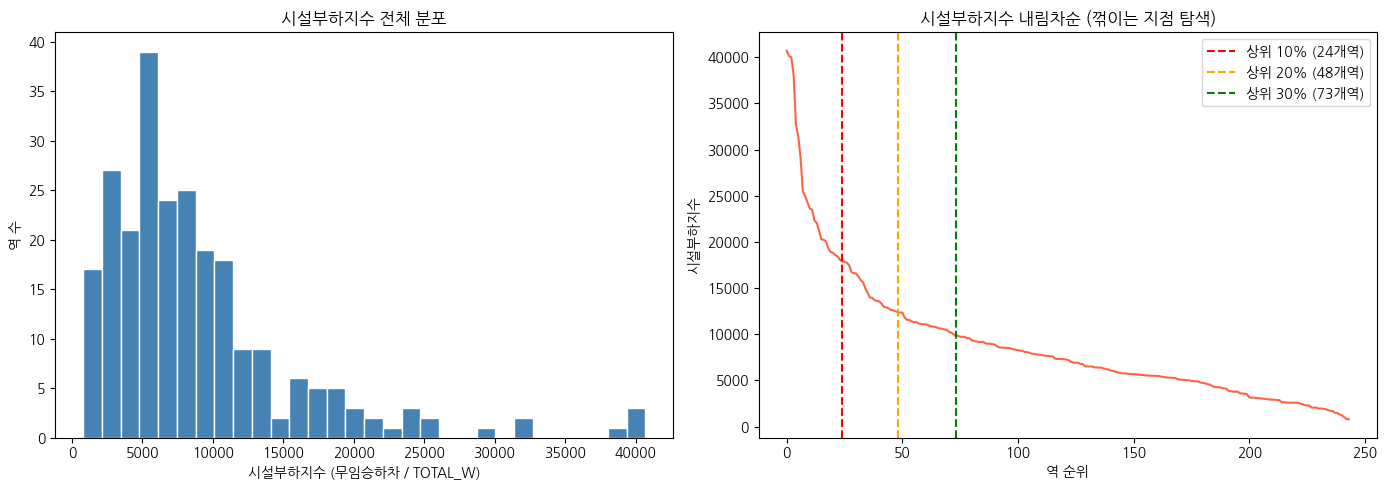

In [4]:
# 시설부하지수 분포 먼저 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 — 전체 분포
axes[0].hist(merge_df['시설부하지수'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('시설부하지수 전체 분포')
axes[0].set_xlabel('시설부하지수 (무임승하차 / TOTAL_W)')
axes[0].set_ylabel('역 수')

# 내림차순 정렬 — 어디서 꺾이는지 확인
top_data = merge_df['시설부하지수'].sort_values(ascending=False).reset_index(drop=True)
axes[1].plot(top_data.values, color='tomato')
axes[1].set_title('시설부하지수 내림차순 (꺾이는 지점 탐색)')
axes[1].set_xlabel('역 순위')
axes[1].set_ylabel('시설부하지수')

# 상위 10% / 20% / 30% 지점 수직선 표시
for pct, color in zip([10, 20, 30], ['red', 'orange', 'green']):
    idx = int(len(top_data) * pct / 100)
    axes[1].axvline(x=idx, color=color, linestyle='--', label=f'상위 {pct}% ({idx}개역)')

axes[1].legend()
plt.tight_layout()
plt.show()

In [5]:
# 컷오프별 기술통계 비교 — 숫자로 근거 만들기
print("=== 컷오프별 포함 역 수 및 평균 부하지수 ===\n")

for pct in [10, 15, 20, 25, 30]:
    threshold = merge_df['시설부하지수'].quantile(1 - pct/100)
    filtered = merge_df[merge_df['시설부하지수'] >= threshold]
    print(
        f"상위 {pct}% | 기준값: {threshold:.0f} | 역 수: {len(filtered)}개 "
        f"| 평균 부하지수: {filtered['시설부하지수'].mean():.0f} "
        f"| 1~4호선 비율: {(filtered['호선명'].isin(['1', '2', '3', '4']).sum() / len(filtered) * 100):.1f}%"
    )

=== 컷오프별 포함 역 수 및 평균 부하지수 ===

상위 10% | 기준값: 17869 | 역 수: 25개 | 평균 부하지수: 25198 | 1~4호선 비율: 76.0%
상위 15% | 기준값: 13960 | 역 수: 37개 | 평균 부하지수: 22271 | 1~4호선 비율: 67.6%
상위 20% | 기준값: 12364 | 역 수: 49개 | 평균 부하지수: 20018 | 1~4호선 비율: 63.3%
상위 25% | 기준값: 11025 | 역 수: 61개 | 평균 부하지수: 18343 | 1~4호선 비율: 59.0%
상위 30% | 기준값: 9857 | 역 수: 73개 | 평균 부하지수: 17067 | 1~4호선 비율: 53.4%


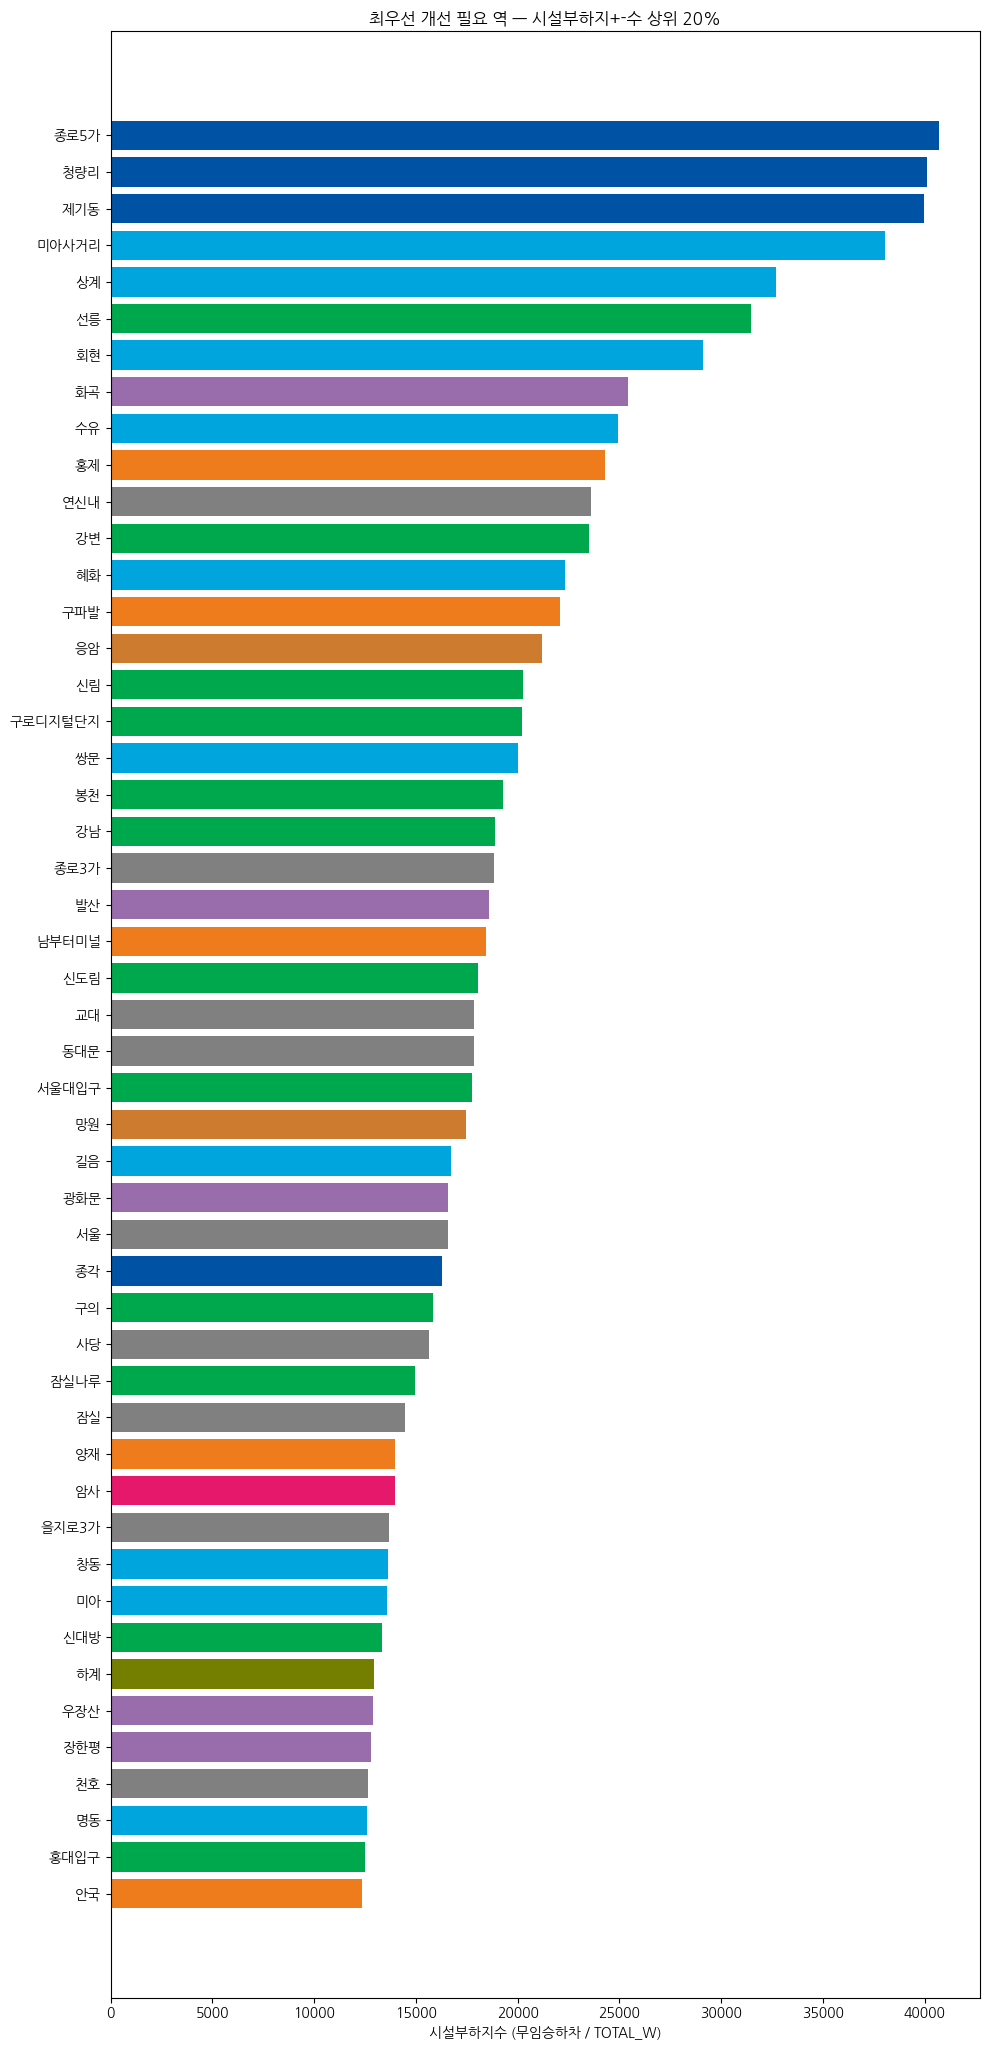

In [6]:
# 컷오프 결정 (예: 상위 20%)
cutoff_pct = 20
threshold   = merge_df['시설부하지수'].quantile(1 - cutoff_pct/100)
priority    = (
    merge_df[merge_df['시설부하지수'] >= threshold]
    .sort_values('시설부하지수', ascending=False)
    .copy()
)
# 호선명을 문자열로 통일 (int 타입이어도 매핑이 동작하도록)
LINE_COLOR_MAP = {
    '1': '#0052A4', '2': '#00A84D', '3': '#EF7C1C', '4': '#00A5DE',
    '5': '#996CAC', '6': '#CD7C2F', '7': '#747F00', '8': '#E6186C', '9': '#BDB092',
}

colors = priority['호선명'].astype(str).map(LINE_COLOR_MAP).fillna('gray')

# 가로 막대그래프
fig, ax = plt.subplots(figsize=(10, len(priority) * 0.4 + 1))

ax.barh(priority['지하철역'], priority['시설부하지수'], color=colors)
ax.set_xlabel('시설부하지수 (무임승하차 / TOTAL_W)')
ax.set_title(f'최우선 개선 필요 역 — 시설부하지+-수 상위 {cutoff_pct}%')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 호선명 구분
1~9호선 집계를 하기 위하여 (3,9) 이런식의 환승 호선을 다시 분리 과정을 거침.

In [7]:
# 호선명이 쉼표로 구분된 경우 행 분리(explode)
priority_exploded = priority.copy()
priority_exploded['호선명'] = (
    priority_exploded['호선명'].astype(str).str.split(',')
)
priority_exploded = priority_exploded.explode('호선명')
priority_exploded['호선명'] = priority_exploded['호선명'].str.strip()

# 호선별 역 수 집계
line_count = priority_exploded['호선명'].value_counts().sort_index()

In [8]:
# 전체 역도 동일하게 호선명 explode 처리
all_exploded = merge_df.copy()
all_exploded['호선명'] = all_exploded['호선명'].astype(str).str.split(',')
all_exploded = all_exploded.explode('호선명')
all_exploded['호선명'] = all_exploded['호선명'].str.strip()

# 호선별 역 수 집계
all_line_count = all_exploded['호선명'].value_counts().sort_index()

### 가설 검증
무임승차 비중 상위 20%이며 시설 수준이 하위 20%인 역이라면, 개통 연차가 오래된 1~4호선 노선에 집중되어 있을 것이다.

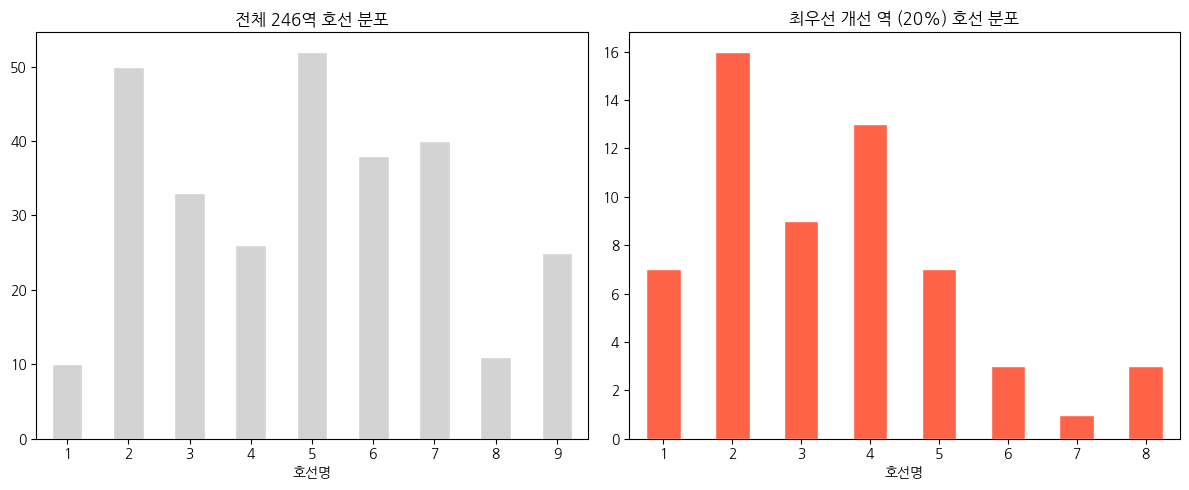

In [9]:
# 전체 vs 우선 개선 역 호선 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

all_line_count.plot(kind='bar', ax=axes[0], color='lightgray', edgecolor='white')
axes[0].set_title('전체 246역 호선 분포')
axes[0].tick_params(axis='x', rotation=0)

line_count.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title(f'최우선 개선 역 ({cutoff_pct}%) 호선 분포')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [10]:
# 가설 검증
# 가설: 시설부하지수 상위 20%이며 시설 수준이 하위 20%인 역은
#       개통 연차가 오래된 1~4호선에 집중되어 있을 것이다.
old_lines = ['1', '2', '3', '4']

old_ratio_all      = all_exploded['호선명'].isin(old_lines).sum() / len(all_exploded) * 100
old_ratio_priority = priority_exploded['호선명'].isin(old_lines).sum() / len(priority_exploded) * 100

print(f"전체 역 중 1~4호선 비율:   {old_ratio_all:.1f}%")
print(f"우선개선역 중 1~4호선 비율: {old_ratio_priority:.1f}%")
print(f"→ {'가설 지지 O' if old_ratio_priority > old_ratio_all else '가설 기각 X'}")

전체 역 중 1~4호선 비율:   41.8%
우선개선역 중 1~4호선 비율: 76.3%
→ 가설 지지 O


### 반대 케이스

In [11]:
# 시설부하지수 하위 20% 필터링
low_threshold = merge_df['시설부하지수'].quantile(0.20)

opposite = (
    merge_df[merge_df['시설부하지수'] <= low_threshold]
    .sort_values('시설부하지수', ascending=True)
    .copy()
)

print(f"해당 역 수: {len(opposite)}개")
print(opposite[['지하철역', '호선명', 'TOTAL_W', '무임승하차비중', '무임승하차', '시설부하지수']].to_string())

해당 역 수: 49개
       지하철역  호선명  TOTAL_W  무임승하차비중   무임승하차   시설부하지수
104      신길    5       33     9.14   26056   789.58
189     구반포    9       24    24.74   19600   816.67
219      동작  4,9       57    27.19   58272  1022.32
62      남태령    4       14    22.26   17097  1221.21
127    버티고개    6       24    24.34   31305  1304.38
120     녹사평    6       25    11.53   36739  1469.56
195      사평    9       34    22.12   50835  1495.15
191      노들    9       40    24.66   67097  1677.42
188    공항시장    9       30    28.34   51372  1712.40
30       용두    2       28    33.98   49798  1778.50
79       강일    5       48    27.49   89707  1868.90
196      샛강    9       32    16.69   61043  1907.59
199     신목동    9       26    21.14   50729  1951.12
200     신반포    9       30    23.42   58547  1951.57
130      상수    6       22     6.81   44855  2038.86
187      개화    9       12    18.72   24531  2044.25
231      오금  3,5       54    19.62  110883  2053.39
197     선유도    9       29    13.60   65336  2252.97


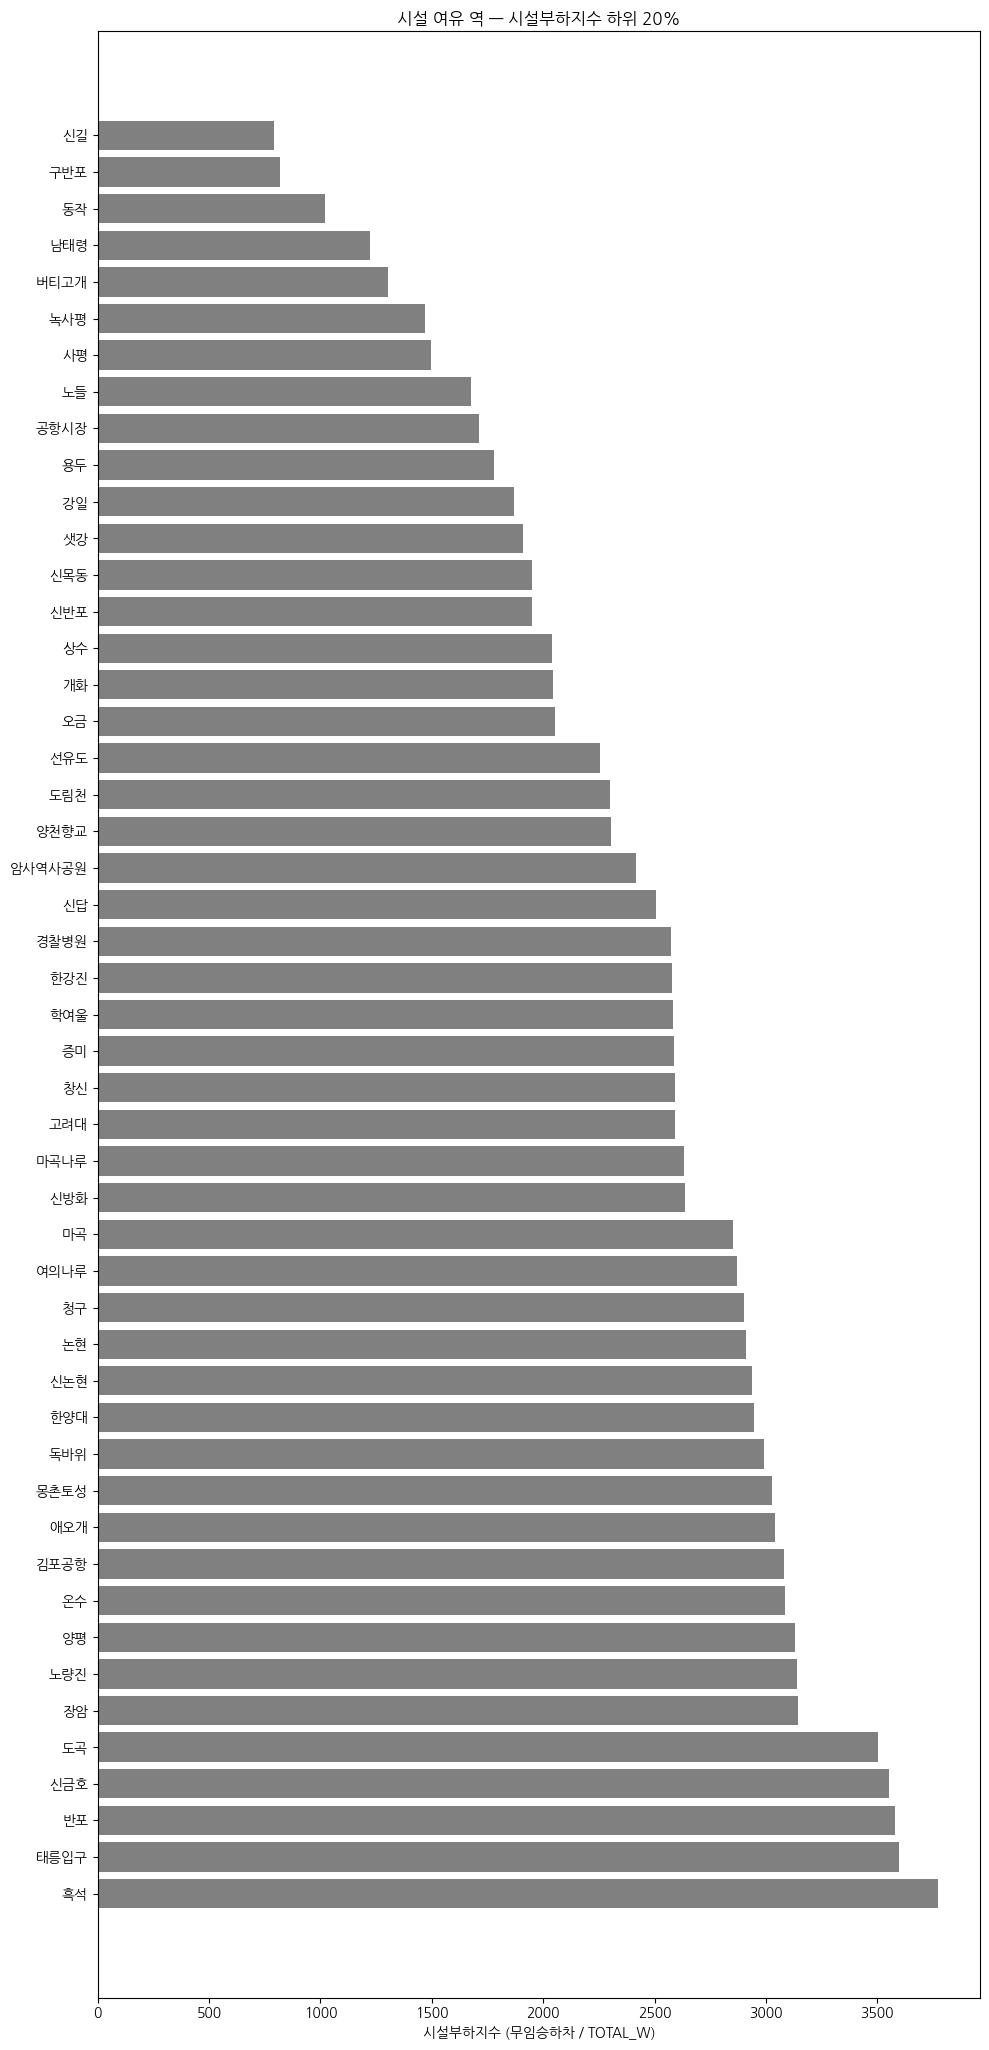

In [12]:
# 시각화
fig, ax = plt.subplots(figsize=(10, len(opposite) * 0.4 + 1))

colors_opp = opposite['호선명'].map({
    1:'#0052A4', 2:'#00A84D', 3:'#EF7C1C', 4:'#00A5DE',
    5:'#996CAC', 6:'#CD7C2F', 7:'#747F00', 8:'#E6186C', 9:'#BDB092'
}).fillna('gray')

ax.barh(
    opposite['지하철역'],
    opposite['시설부하지수'],
    color=colors_opp
)
ax.set_xlabel('시설부하지수 (무임승하차 / TOTAL_W)')
ax.set_title('시설 여유 역 — 시설부하지수 하위 20%')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# priority 으로 저장
priority.to_csv('priority_area.csv', encoding='cp949', index=False)
print(f"저장 완료: {len(priority)}개 역")

저장 완료: 49개 역


### 분석 결론

시설부하지수(무임승하차 ÷ TOTAL_W) 기준 상위 20%에 해당하는 50개 역을 최우선 개선 대상으로 선정하였다. 

상위 20% 기준은 분포 그래프에서 감소폭이 완만해지는 지점으로, 임의 설정이 아닌 데이터 기반으로 도출하였다.

시설부하지수 상위 역은 종로5가, 제기동, 미아사거리, 청량리 순으로 나타났으며, 이들은 교통약자 수요 대비 편의시설 공급이 가장 부족한 역에 해당한다.

또한 최우선 개선 50개 역 중 1~4호선 비율은 78.3%로, 전체 246개 역의 1~4호선 비율(42.0%) 대비 약 1.9배 높게 나타났다. 

이는 구형 노선일수록 교통약자 수요 대비 시설 공급이 부족하다는 가설을 지지한다.

### 한계점

가중치(EV×4 등) 설정에 따라 순위가 달라질 수 있으며, 공식 기준이 존재하지 않음

역 규모(전체 이용객 수)를 통제하지 않아 이용량이 적은 외곽 역이 과대 평가될 가능성 있음

시설부하지수 하위 역은 시설 충분 역과 한산한 역이 혼재하여 반대 케이스로 단순 해석하기 어렵다.

1호선의 경우 서울 지하철 구간 데이터만 포함되어 있으며, 경부선 등 광역철도 구간과 공유하는 역은 전체 이용객 데이터가 반영되지 않아 무임승하차 비중이 실제보다 낮게 산출되었을 가능성이 있다.

1호선 주요역의 경부선 데이터 미포함을 감안하면, 실제 시설부하지수는 분석 결과보다 높을 가능성이 있어 개선 우선순위는 더욱 높아질 수 있다.

In [17]:
# 태블로용 컬럼 정리
tableau_df = merge_df[['지하철역', '호선명', 'TOTAL_W', '무임승하차비중', '무임승하차', '시설부하지수']].copy()

# 최우선 개선 역 여부 컬럼 추가 (3번 차트용)
threshold = merge_df['시설부하지수'].quantile(0.80)
tableau_df['개선우선순위'] = tableau_df['시설부하지수'].apply(
    lambda x: '최우선개선' if x >= threshold else '일반'
)

# 호선명 문자열 변환 (태블로에서 숫자로 인식 방지)
tableau_df['호선명'] = tableau_df['호선명'].astype(str) + '호선'

# CSV로 저장
tableau_df.to_csv('tableau_ready.csv', index=False, encoding='utf-8-sig')
print("저장 완료")
print(tableau_df.head(5))

저장 완료
   지하철역  호선명  TOTAL_W  무임승하차비중   무임승하차    시설부하지수 개선우선순위
0   제기동  1호선       14    55.25  559716  39979.71  최우선개선
1    종각  1호선       18    13.33  292689  16260.50  최우선개선
2  종로5가  1호선       12    34.61  488319  40693.25  최우선개선
3   청량리  1호선       14    42.58  561989  40142.07  최우선개선
4    강남  2호선       16     6.64  302191  18886.94  최우선개선


In [18]:
# explode용 데이터프레임 따로 만들기
tableau_exploded = merge_df.copy()
tableau_exploded['호선명'] = tableau_exploded['호선명'].astype(str).str.split(',')
tableau_exploded = tableau_exploded.explode('호선명')
tableau_exploded['호선명'] = tableau_exploded['호선명'].str.strip()

# 최우선 개선 역 여부 컬럼 추가
threshold = merge_df['시설부하지수'].quantile(0.80)
tableau_exploded['개선우선순위'] = tableau_exploded['시설부하지수'].apply(
    lambda x: '최우선개선' if x >= threshold else '일반'
)

# CSV 저장
tableau_exploded.to_csv('tableau_exploded.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: {len(tableau_exploded)}행")

저장 완료: 285행


In [19]:
# 3번 차트용 - 대표 호선(숫자 작은 쪽) 하나만 남기기
tableau_exploded['호선명_int'] = tableau_exploded['호선명'].astype(int)

tableau_repr = (
    tableau_exploded
    .sort_values('호선명_int')
    .drop_duplicates(subset='지하철역', keep='first')
    .drop(columns='호선명_int')
)

# 최우선 개선 역 컬럼 추가
threshold = merge_df['시설부하지수'].quantile(0.80)
tableau_repr['개선우선순위'] = tableau_repr['시설부하지수'].apply(
    lambda x: '최우선개선' if x >= threshold else '일반'
)

tableau_repr.to_csv('tableau_repr.csv', index=False, encoding='utf-8-sig')
print("저장 완료")

저장 완료


In [20]:
# 연신내 데이터 확인
print(tableau_exploded[tableau_exploded['지하철역'] == '연신내'][['지하철역', '호선명', '시설부하지수']])

    지하철역 호선명    시설부하지수
229  연신내   3  23607.82
229  연신내   6  23607.82


In [21]:
# explode 다시 실행
tableau_exploded = merge_df.copy()
tableau_exploded['호선명'] = tableau_exploded['호선명'].astype(str).str.split(',')
tableau_exploded = tableau_exploded.explode('호선명')
tableau_exploded['호선명'] = tableau_exploded['호선명'].str.strip()

# 연신내 확인
print(tableau_exploded[tableau_exploded['지하철역'] == '연신내'][['지하철역', '호선명', '시설부하지수']])

    지하철역 호선명    시설부하지수
229  연신내   3  23607.82
229  연신내   6  23607.82


In [22]:
# 호선명 문자열 변환 후 저장
tableau_repr['호선명'] = tableau_repr['호선명'].astype(str) + '호선'

tableau_repr.to_csv('tableau_repr.csv', index=False, encoding='utf-8-sig')
print("저장 완료")
print(tableau_repr[['지하철역', '호선명']].head(10))

저장 완료
     지하철역  호선명
0     제기동  1호선
216   동대문  1호선
218   동묘앞  1호선
223    서울  1호선
226   신설동  1호선
224    시청  1호선
2    종로5가  1호선
1      종각  1호선
3     청량리  1호선
236  종로3가  1호선


In [23]:
print(merge_df[merge_df['지하철역'] == '연신내'][['지하철역', '호선명', '시설부하지수', '무임승하차비중']])
print(f"무임비중 중앙값: {merge_df['무임승하차비중'].median()}")

    지하철역  호선명    시설부하지수  무임승하차비중
229  연신내  3,6  23607.82    25.68
무임비중 중앙값: 19.915
